# Checkpoint 5 - Statistical Computing with R & Python + Machine Learning & Modelling

**Curso:** Tecnólogo em Inteligência Artificial - FIAP  
**Integrantes:** Maria Eduarda, Giovanna, Arthur Costa Donaire e Felipe  
**RMs:** Maria Eduarda - 572612 | Giovanna - 570989 | Arthur Costa Donaire - 571283 | Felipe - 573263

## Objetivo
Integrar análise estatística descritiva e probabilística com modelagem não supervisionada, utilizando o dataset **Wines**. Na parte de Machine Learning, o algoritmo K-means será utilizado para agrupar vinhos com características semelhantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
df = pd.read_csv('wine.csv')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
display(df.head())

Linhas: 178 | Colunas: 14


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Statistical Computing with R & Python

Foram escolhidas duas variáveis quantitativas:

- **Alcohol**: teor alcoólico dos vinhos.
- **Malic.acid**: concentração de ácido málico.

A escolha permite comparar uma variável de menor dispersão relativa com outra mais heterogênea.


### Alcohol


,Frequência,Frequência relativa (%),Frequência acumulada,Freq. rel. acumulada (%)
Alcohol,,,,
"(11.026, 11.452]",3,1.69,3,1.69
"(11.452, 11.874]",15,8.43,18,10.11
"(11.874, 12.297]",23,12.92,41,23.03
"(12.297, 12.719]",28,15.73,69,38.76
"(12.719, 13.141]",28,15.73,97,54.49
"(13.141, 13.563]",30,16.85,127,71.35
"(13.563, 13.986]",29,16.29,156,87.64
"(13.986, 14.408]",20,11.24,176,98.88
"(14.408, 14.83]",2,1.12,178,100.00


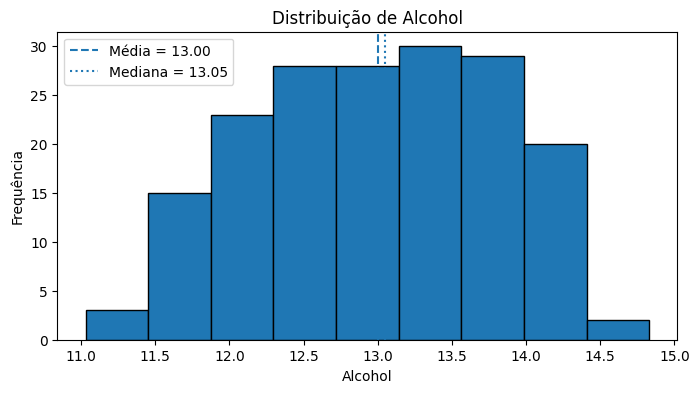


### Malic.acid


,Frequência,Frequência relativa (%),Frequência acumulada,Freq. rel. acumulada (%)
Malic.acid,,,,
"(0.735, 1.302]",21,11.80,21,11.80
"(1.302, 1.864]",68,38.20,89,50.00
"(1.864, 2.427]",25,14.04,114,64.04
"(2.427, 2.989]",16,8.99,130,73.03
"(2.989, 3.551]",16,8.99,146,82.02
"(3.551, 4.113]",17,9.55,163,91.57
"(4.113, 4.676]",8,4.49,171,96.07
"(4.676, 5.238]",4,2.25,175,98.31
"(5.238, 5.8]",3,1.69,178,100.00


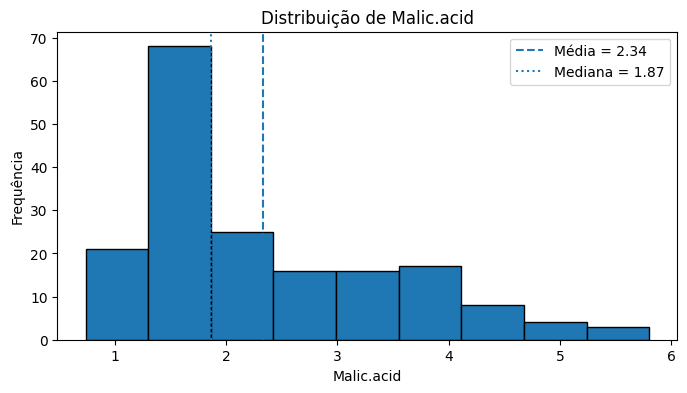

In [2]:
def tabela_frequencia(serie, bins=9):
    classes = pd.cut(serie, bins=bins)
    freq = classes.value_counts().sort_index()
    out = pd.DataFrame({'Frequência': freq})
    out['Frequência relativa (%)'] = out['Frequência'] / len(serie) * 100
    out['Frequência acumulada'] = out['Frequência'].cumsum()
    out['Freq. rel. acumulada (%)'] = out['Frequência relativa (%)'].cumsum()
    return out

for col in ['Alcohol', 'Malic.acid']:
    print(f'\n### {col}')
    display(tabela_frequencia(df[col]).round(2))
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=9, edgecolor='black')
    plt.axvline(df[col].mean(), linestyle='--', label=f'Média = {df[col].mean():.2f}')
    plt.axvline(df[col].median(), linestyle=':', label=f'Mediana = {df[col].median():.2f}')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

### Interpretação das distribuições

- **Alcohol** apresenta maior concentração dos valores em torno de 13 e baixa dispersão relativa.
- **Malic.acid** é mais espalhada e possui assimetria à direita, com observações de valores mais altos formando uma cauda mais longa.

In [3]:
def resumo_descritivo(serie):
    q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
    return pd.Series({
        'Média': serie.mean(),
        'Mediana': serie.median(),
        'Moda': serie.mode().iloc[0],
        'Mínimo': serie.min(),
        'Máximo': serie.max(),
        'Amplitude': serie.max() - serie.min(),
        'Variância': serie.var(),
        'Desvio padrão': serie.std(),
        'Coef. variação (%)': serie.std()/serie.mean()*100,
        'Q1': q1, 'Q2': q2, 'Q3': q3,
        'IQR': q3-q1
    })

resumo = pd.concat({
    'Alcohol': resumo_descritivo(df['Alcohol']),
    'Malic.acid': resumo_descritivo(df['Malic.acid'])
}, axis=1)
display(resumo.round(4))

,Alcohol,Malic.acid
Média,13.0006,2.3363
Mediana,13.0500,1.8650
Moda,12.3700,1.7300
Mínimo,11.0300,0.7400
Máximo,14.8300,5.8000
Amplitude,3.8000,5.0600
Variância,0.6591,1.2480
Desvio padrão,0.8118,1.1171
Coef. variação (%),6.2445,47.8159
Q1,12.3625,1.6025


### Interpretação da análise descritiva

O coeficiente de variação de **Alcohol** é aproximadamente **6,24%**, indicando baixa dispersão relativa. Já **Malic.acid** apresenta coeficiente de variação próximo de **47,82%**, mostrando muito mais heterogeneidade. Os quartis reforçam essa diferença: 50% dos valores de Alcohol ficam aproximadamente entre 12,36 e 13,68, enquanto 50% dos valores de Malic.acid ficam entre 1,60 e 3,08.

In [4]:
def prob_normal_e_empirica(serie, tipo, a, b=None):
    mu, sigma = serie.mean(), serie.std()
    if tipo == 'acima':
        p_normal = 1 - norm.cdf(a, loc=mu, scale=sigma)
        p_emp = (serie > a).mean()
    else:
        p_normal = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)
        p_emp = ((serie > a) & (serie < b)).mean()
    return p_normal, p_emp

resultados_prob = []
for var, descricao, tipo, a, b in [
    ('Alcohol', 'P(X > 13,5)', 'acima', 13.5, None),
    ('Alcohol', 'P(12,5 < X < 14,0)', 'entre', 12.5, 14.0),
    ('Malic.acid', 'P(X > 3,0)', 'acima', 3.0, None),
    ('Malic.acid', 'P(1,5 < X < 2,5)', 'entre', 1.5, 2.5),
]:
    pn, pe = prob_normal_e_empirica(df[var], tipo, a, b)
    resultados_prob.append([var, descricao, pn, pe])

probabilidades = pd.DataFrame(resultados_prob, columns=['Variável','Cálculo','Prob. normal','Freq. empírica'])
probabilidades['Prob. normal (%)'] = probabilidades['Prob. normal']*100
probabilidades['Freq. empírica (%)'] = probabilidades['Freq. empírica']*100
display(probabilidades[['Variável','Cálculo','Prob. normal (%)','Freq. empírica (%)']].round(2))

,Variável,Cálculo,Prob. normal (%),Freq. empírica (%)
0,Alcohol,"P(X > 13,5)",26.92,30.90
1,Alcohol,"P(12,5 < X < 14,0)",62.21,55.62
2,Malic.acid,"P(X > 3,0)",27.62,26.40
3,Malic.acid,"P(1,5 < X < 2,5)",33.12,46.07


### Interpretação probabilística

A distribuição Normal foi utilizada como **aproximação teórica**. Para Alcohol, a aproximação é razoável porque a distribuição é relativamente concentrada e menos assimétrica. Para Malic.acid, a assimetria à direita faz com que as probabilidades teóricas possam se afastar mais das frequências empíricas observadas. Por isso, apresentamos lado a lado o cálculo Normal e a frequência real do dataset.

## 2. Machine Learning & Modelling - K-means

### 2.1 Introdução
O objetivo desta etapa é agrupar vinhos semelhantes sem utilizar a classe original como resposta. O K-means é um algoritmo não supervisionado que forma grupos minimizando a distância dos registros aos centróides.

### 2.2 Pré-processamento
A coluna **Wine** é removida porque identifica a classe original e não deve participar da descoberta dos grupos. Em seguida, verificamos valores nulos e padronizamos as variáveis com `StandardScaler`, pois o K-means é sensível à escala das features.

In [5]:
X = df.drop(columns=['Wine'])
print('Quantidade de valores nulos:', X.isnull().sum().sum())
print('Features utilizadas:', X.shape[1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Média aproximada após padronização:', np.round(X_scaled.mean(axis=0).mean(), 6))
print('Desvio padrão médio após padronização:', np.round(X_scaled.std(axis=0).mean(), 6))

Quantidade de valores nulos: 0
Features utilizadas: 13
Média aproximada após padronização: -0.0
Desvio padrão médio após padronização: 1.0


### 2.3 Escolha do número de clusters: Elbow e Silhouette

Testamos valores de `k` entre 2 e 8. O método Elbow avalia a redução da inércia e o Silhouette Score mede o quão bem separados e coesos estão os grupos.

,k,Inércia,Silhouette
0,2,1658.7589,0.2593
1,3,1277.9285,0.2849
2,4,1175.4283,0.2602
3,5,1109.5127,0.2016
4,6,1046.0023,0.2372
5,7,981.5952,0.2036
6,8,935.2012,0.1570


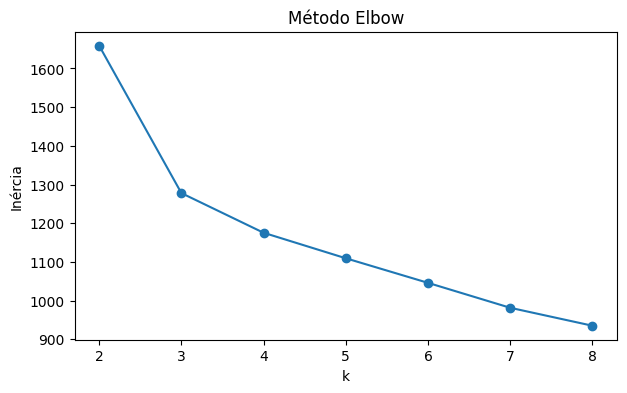

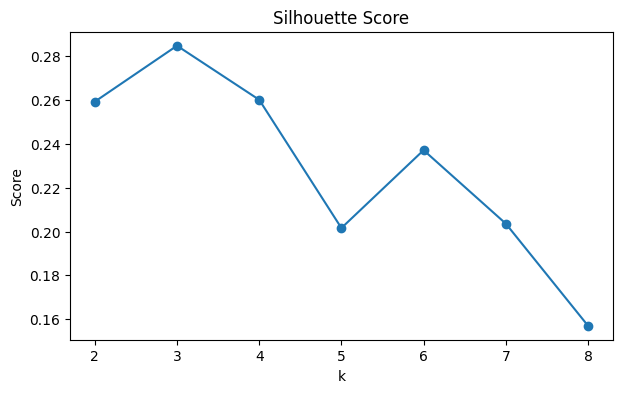

In [6]:
ks = range(2, 9)
inercias = []
silhuetas = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels))

comparacao_k = pd.DataFrame({'k': list(ks), 'Inércia': inercias, 'Silhouette': silhuetas})
display(comparacao_k.round(4))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inercias, marker='o')
plt.title('Método Elbow')
plt.xlabel('k')
plt.ylabel('Inércia')
plt.xticks(list(ks))
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), silhuetas, marker='o')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.xticks(list(ks))
plt.show()

O maior **Silhouette Score** ocorre em **k = 3** (aproximadamente **0,2849**). O gráfico do Elbow também mostra uma queda forte de inércia até a região de três grupos. Portanto, adotamos **3 clusters** como solução final.

### 2.4 Ajuste final do K-means e análise dos grupos

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster = df.copy()
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

contagens = df_cluster['Cluster'].value_counts().sort_index()
medias = df_cluster.groupby('Cluster').mean(numeric_only=True)
perfil = medias[['Alcohol','Malic.acid','Ash','Phenols','Flavanoids','Color.int','Hue','Proline']].copy()
perfil.insert(0, 'n', contagens)
display(perfil.round(2))

,n,Alcohol,Malic.acid,Ash,Phenols,Flavanoids,Color.int,Hue,Proline
Cluster,,,,,,,,,
0,65,12.25,1.90,2.23,2.25,2.05,2.97,1.06,510.17
1,51,13.13,3.31,2.42,1.68,0.82,7.23,0.69,619.06
2,62,13.68,2.00,2.47,2.85,3.00,5.45,1.07,1100.23


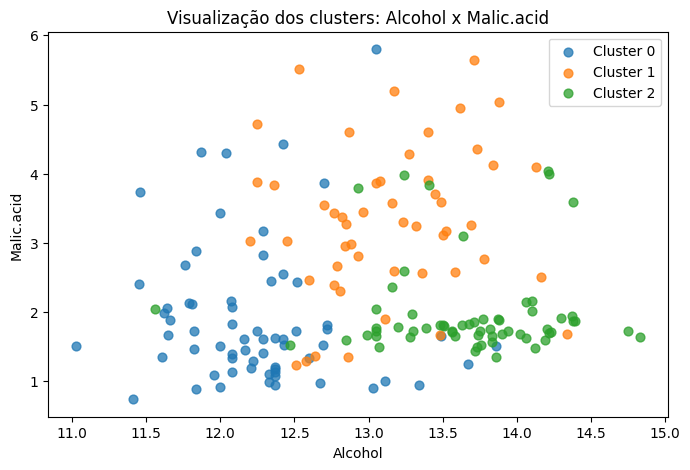

In [8]:
plt.figure(figsize=(8,5))
for c in sorted(df_cluster['Cluster'].unique()):
    grupo = df_cluster[df_cluster['Cluster'] == c]
    plt.scatter(grupo['Alcohol'], grupo['Malic.acid'], s=40, alpha=0.75, label=f'Cluster {c}')
plt.title('Visualização dos clusters: Alcohol x Malic.acid')
plt.xlabel('Alcohol')
plt.ylabel('Malic.acid')
plt.legend()
plt.show()

### Interpretação dos clusters

- **Cluster 0 (65 vinhos):** menor teor alcoólico médio, menor intensidade de cor e menor Proline. É o grupo de perfil mais leve nessas medidas.
- **Cluster 1 (51 vinhos):** maior média de `Malic.acid` e maior intensidade de cor. Considerando o ácido málico como referência de acidez, é o grupo mais ácido.
- **Cluster 2 (62 vinhos):** maior teor alcoólico médio e Proline muito mais alto, além de médias elevadas de fenóis e flavonoides.

Essas diferenças mostram que o K-means conseguiu separar perfis químicos distintos a partir das variáveis padronizadas.

## 3. Conclusão

A análise estatística mostrou que **Alcohol** é uma variável relativamente homogênea, enquanto **Malic.acid** possui dispersão bem maior e assimetria mais evidente. Na etapa de Machine Learning, a padronização foi necessária para tornar as escalas comparáveis. Os métodos Elbow e Silhouette sustentaram a escolha de **k = 3**, e os três clusters apresentaram diferenças claras em álcool, ácido málico, intensidade de cor, compostos fenólicos e Proline.

Dessa forma, o trabalho integra análise estatística, probabilidade, pré-processamento e clusterização de maneira consistente com o objetivo proposto.